# Step 1: Installing and Importing Libraries

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Step 2: Loading the Dataset
Here we will load the dataset and use the parse_dates parameter to convert the Date column to the DatetimeIndex format.

In [34]:
df = pd.read_csv('../../../../../0-Dataset_And_Playground/1-AI-Dataset/stock_data.csv', 
                 parse_dates=True, 
                 index_col="Date")
df.head(n=20)

,Unnamed: 0,Open,High,Low,Close,Volume,Name
Date,,,,,,,
2006-01-03,NaN,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,NaN,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,NaN,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,NaN,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,NaN,43.10,43.66,42.82,43.42,16268338,AABA
2006-01-10,NaN,42.96,43.34,42.34,42.98,16288580,AABA
2006-01-11,NaN,42.19,42.31,41.72,41.87,26192772,AABA
2006-01-12,NaN,41.92,41.99,40.76,40.89,18921686,AABA
2006-01-13,NaN,41.00,41.08,39.62,39.90,30966185,AABA


# Step 3: Cleaning of Data
We will drop columns from the dataset that are not important for our visualization.

In [35]:
df.drop(columns='Unnamed: 0', inplace =True)
df.head(n=20)

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA
2006-01-10,42.96,43.34,42.34,42.98,16288580,AABA
2006-01-11,42.19,42.31,41.72,41.87,26192772,AABA
2006-01-12,41.92,41.99,40.76,40.89,18921686,AABA
2006-01-13,41.00,41.08,39.62,39.90,30966185,AABA


# Step 4: Plotting High Stock Prices
Since the 'High'column is of continuous data type we will use line graph to visualize it.
- sns.lineplot(data=df, x=df.index, y='High', label='High Price', color='blue'): Plots High prices over time using the datetime index on x-axis.

Text(0.5, 1.0, 'Share Highest Price Over Time')

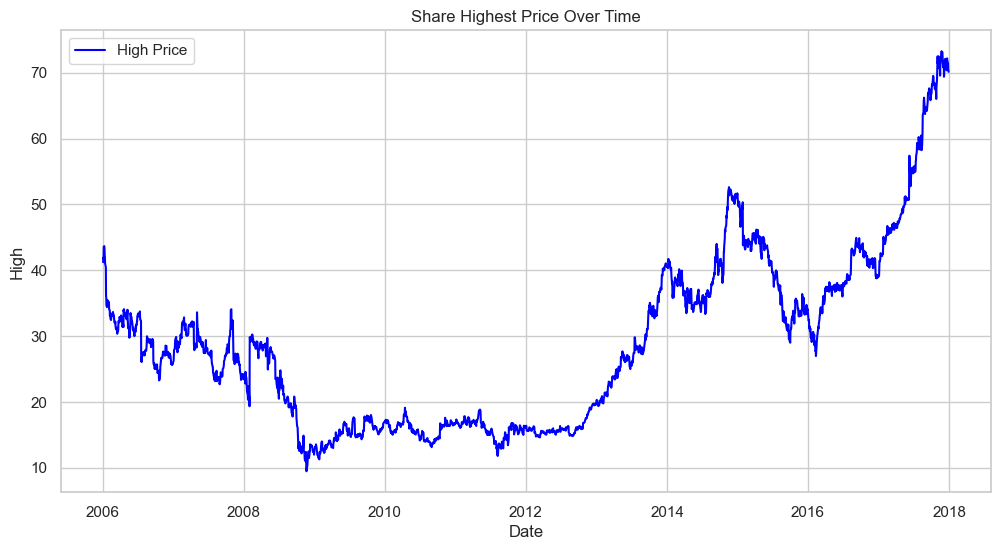

In [36]:
sns.set(style="whitegrid") 

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='High', label='High Price', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')

# Step 5: Resampling Data
To better understand the trend of the data we will use the resampling method which provide a clearer view of trends and patterns when we are dealing with daily data.
- df_resampled = df.resample('M').mean(numeric_only=True): Resamples data to monthly frequency and calculates the mean of all numeric columns for each month.

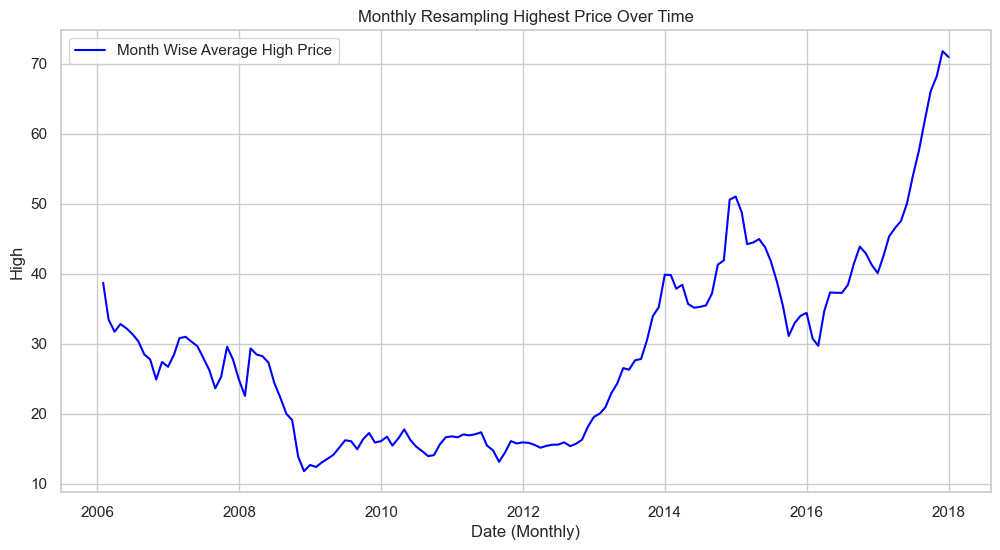

In [37]:
# M: Month (Old Version) ME: Month End (New version)
# numeric_only: Just Numerical Column
df_resampled = df.resample('ME').mean(numeric_only=True) 

sns.set(style="whitegrid") 

plt.figure(figsize=(12, 6))  
sns.lineplot(data=df_resampled, x=df_resampled.index, y='High', label='Month Wise Average High Price', color='blue')

plt.xlabel('Date (Monthly)')
plt.ylabel('High')
plt.title('Monthly Resampling Highest Price Over Time')

plt.show()

# Step 6: Detecting Seasonality with Autocorrelation
We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

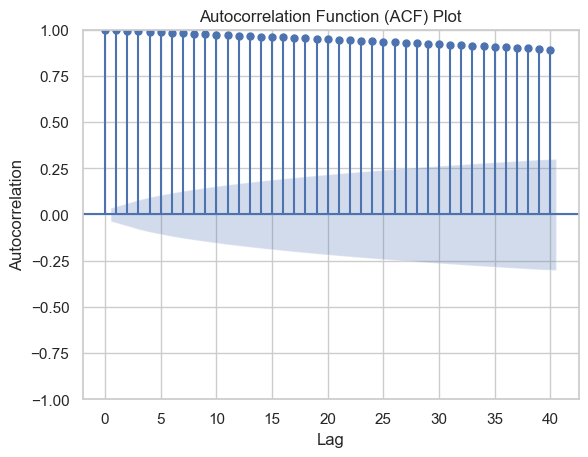

In [38]:
if 'Date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

# وقتی می‌گوییم Lag 40، یعنی مدل کامپیوتر تو، به کلِ تاریخچه چند ساله نگاه کرده و این سوال را پرسیده:
# «در طول این چند سال، به طور متوسط، قیمتِ "هر روز" چقدر به قیمتِ "۴۰ روز قبلش" شبیه بوده است؟»
plt.figure(figsize=(12, 6))
plot_acf(df['High'], lags=40)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

# Step 7: Testing Stationarity with Augmented Dickey-Fuller (ADF) test
We will perform the ADF test to formally test for stationarity.

In [39]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['High'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])


# The output of this test is loudly screaming: "This data is toxic for your AI model!"

# p-value: To prove that the data is Stationary, this number must be less than or equal to 0.05 
# (meaning we are 95% confident that the data has no trend). 
# Our value here is 0.991 (nearly 100%!). This indicates with absolute certainty that 
# your raw price data is Non-Stationary and contains a highly volatile/escaping trend.

# ADF Statistic (0.767): This is the score or test statistic that the ADF test has assigned to your data.

# Critical Values: These represent the thresholds or the "red lines" of the test. 
# The threshold at the 5% significance level is equal to -2.86.

# Mathematical Rule of the ADF Test: For the data to be Stationary, the ADF Statistic must be 
# more negative and smaller than the Critical Values. It needs to cross the thresholds 
# and move towards larger negative numbers (like -3 or -4). 
# However, your data score is +0.767! This number is not only non-negative, but it is actually positive 
# and miles away from the stationarity red line of -2.86. 
# Thus, the non-stationarity of the data is cross-confirmed by another metric.

ADF Statistic: 0.7671404880535945
p-value: 0.9910868050318213
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


# Step 8: Differencing to Achieve Stationarity
Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality.

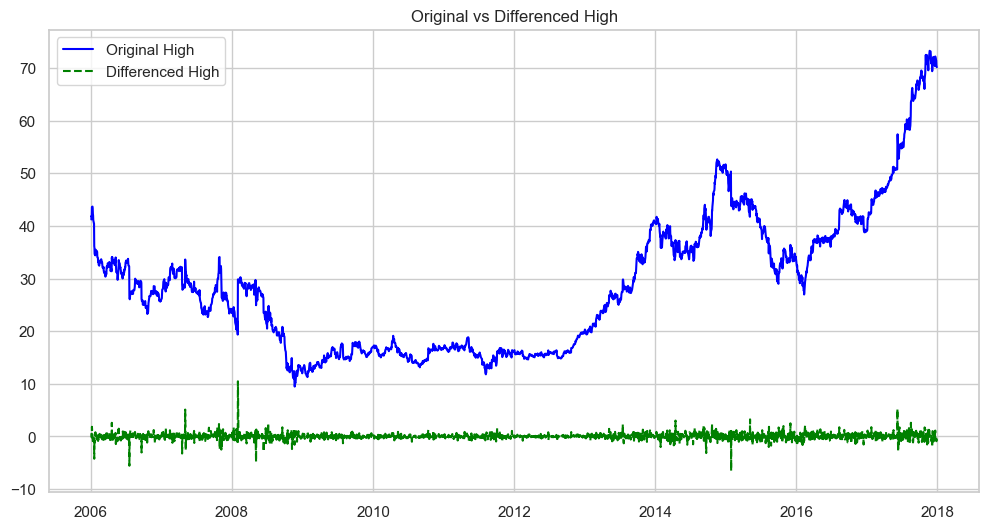

In [40]:
# high_diff(t)= High(t) −High(t−1)
df['high_diff'] = df['High'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_diff'], label='Differenced High', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced High')
plt.show()

# Step 9: Smoothing Data with Moving Average
- df['High'].diff(): helps in calculating the difference between consecutive values in the High column. This differencing operation is used to transform a time series into a new series that represents the changes between consecutive observations.

This calculates the moving average of the High column with a window size of 120(A quarter), creating a smoother curve in the high_smoothed series. The plot compares the original High values with the smoothed version.

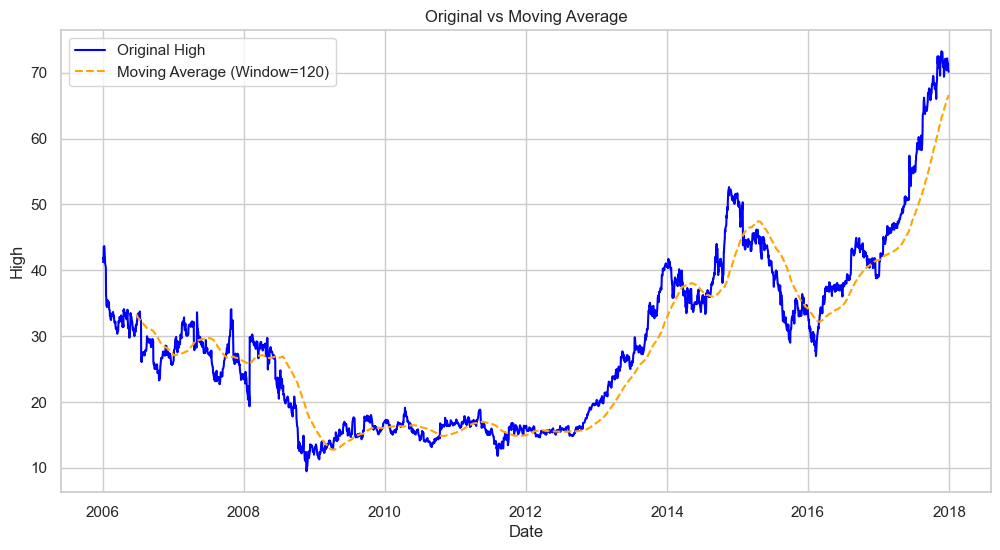

In [41]:
window_size = 120
df['high_smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

# Step 10: Original Data vs. Differenced Data
Printing the original and differenced data side by side we get:

In [46]:
df_combined = pd.concat([df['High'], df['high_diff']], axis=1)

df_combined.head(n=20)

,High,high_diff
Date,,
2006-01-04,41.90,0.68
2006-01-05,41.73,-0.17
2006-01-06,43.57,1.84
2006-01-09,43.66,0.09
2006-01-10,43.34,-0.32
2006-01-11,42.31,-1.03
2006-01-12,41.99,-0.32
2006-01-13,41.08,-0.91
2006-01-17,40.39,-0.69


Hence the high_diff column represents the differences between consecutive high values. The first value of high_diff is NaN because there is no previous value to calculate the difference.

As there is a NaN value we will drop that proceed with our test:

In [43]:
df.dropna(subset=['high_diff'], inplace=True)
df['high_diff'].head()

Date
2006-01-04    0.68
2006-01-05   -0.17
2006-01-06    1.84
2006-01-09    0.09
2006-01-10   -0.32
Name: high_diff, dtype: float64

After that if we conduct the Augmented Dickey-Fuller(ADF) test:

In [44]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['high_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -12.14836747834325
p-value: 1.5912766134148351e-22
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


Based on the ADF Statistic we reject the null hypothesis and conclude that we have enough evidence to reject the null hypothesis.